In [1]:
# import full sbpio functionalities 
from sbpio import *

In [2]:
# instantiate file's metadata and set it ready for job 
fname= '20240318161016.segy'
s = sbp(fname)

Loading data...


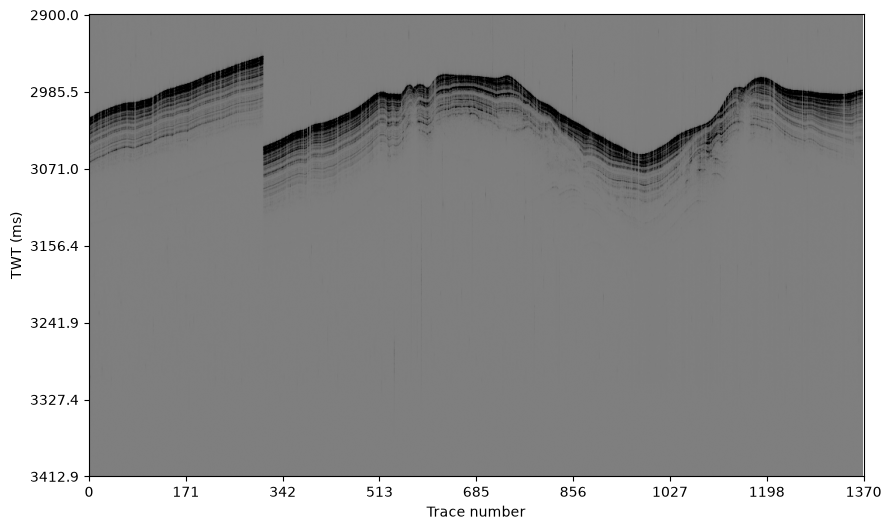

In [3]:
# optionally load data 
s.load()
# plot profile's envelope attribute  
s.show()

#### Delay correction

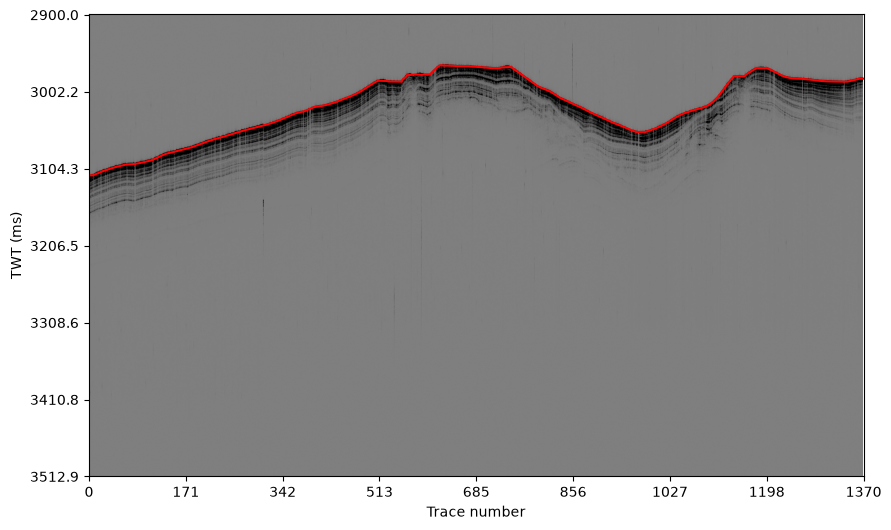

In [4]:
# correct delay 
s.correct_delay()
# plot profile after correction 
s.show(seafloor=True) # Qc that seafloor is smooth and doesn't have outliers. if water depth wasn't written in the header, we need to insert it. 

#### Applying Time-varying gain

Calculating envelope…


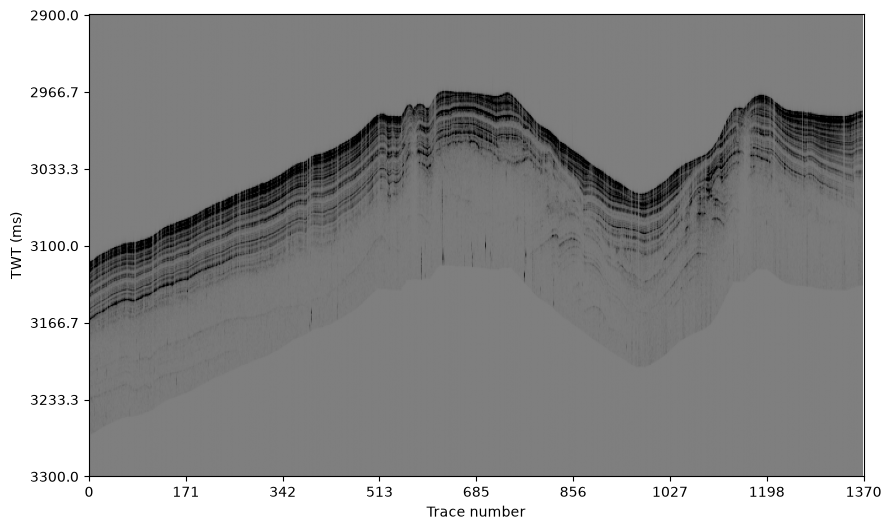

In [5]:
# there are 4 buit-in methods.
# default is gamma tvg 
s.tvg_gain(method = 1,
           offset = 50, 
           realize = 0) # set realize=False if you want to try multiple method before applying to data

s.show(t1 = 3300) # plot data until time 3300 ms

#### Crop data

In [6]:
# we don't need any data after 3300 ms. we can crop that and save us some storage 
s.crop(t1 = 3300) # when we export data, only the data till 3300 will be exported 

#### Navigation 

In [29]:
# check coordinate system
u = s.navs.units if isinstance(s.navs.units, int) else s.navs.units[0]
units = {1:'Meters',
        2:'Arc seconds',
        3:'Decimal degrees', 
        4:'Degree Minute Seconds'}
print(f"Coordinates are in {units[u]}")

Coordinates are in Arc seconds


In [30]:
# coordinate dataframe
sp = s.navs.shot_points() # This function reads coordinates from headers and overwrite any coordinates with the original ones. 
sp 

,File_name,Trace,Shotpoint,Lat,Long
0,20240318161016.segy,1,3689,116544.176,-274293.696
1,20240318161016.segy,2,3690,116544.984,-274293.536
2,20240318161016.segy,3,3691,116545.272,-274293.504
3,20240318161016.segy,4,3692,116545.872,-274293.376
4,20240318161016.segy,5,3693,116546.656,-274293.216
...,...,...,...,...,...
1365,20240318161016.segy,1366,5054,116979.728,-274470.304
1366,20240318161016.segy,1367,5055,116979.736,-274471.136
1367,20240318161016.segy,1368,5056,116979.720,-274472.064
1368,20240318161016.segy,1369,5057,116979.712,-274472.864


#### Export navs
For now, export navs before any coordinate conversion

In [31]:
# Export line shapefile 
s.navs.to_shp('Nav_test_tracklines2', 
              line= True, # True to write polyline shapefile
              append_if_exist=False, # if True and you have shapefile with the same name, this will be merged with the old shapfile
             )

# Export point shapefile 
s.navs.to_shp('Nav_test_shotpoints2', 
              line= False, # True to write polyline shapefile
              append_if_exist=False, # if True and you have shapefile with the same name, this will be merged with the old shapfile
             )

'Nav_test_tracklines2_1.shp' exported successfully.
'Nav_test_shotpoints2_1.shp' exported successfully.


#### Export SBP 

In [32]:
# convert coordinates from Arc seconds to UTM zone 19 
s.navs.coords_2_utm(out_projection='EPSG:32619')
s.navs.shotpoints # after correction, do not call navs.shot_points(). instead call navs.shotpoints to check new coordinates. 

,File_name,Trace,Shotpoint,Lat,Long
0,20240318161016.segy,1,3689,360466270,-17738345
1,20240318161016.segy,2,3690,360468738,-17737756
2,20240318161016.segy,3,3691,360469622,-17737612
3,20240318161016.segy,4,3692,360471453,-17737151
4,20240318161016.segy,5,3693,360473847,-17736568
...,...,...,...,...,...
1365,20240318161016.segy,1366,5054,361843377,-18109687
1366,20240318161016.segy,1367,5055,361843551,-18111864
1367,20240318161016.segy,1368,5056,361843667,-18114297
1368,20240318161016.segy,1369,5057,361843786,-18116393


In [33]:
# check coordinate system
u = s.navs.units if isinstance(s.navs.units, int) else s.navs.units[0]
units = {1:'Meters',
        2:'Arc seconds',
        3:'Decimal degrees', 
        4:'Degree Minute Seconds'}
print(f"Coordinates are in {units[u]}")

Coordinates are in Meters


In [34]:
# SBPIO assumes that the input is a full-waveform data 
# We have the option to export either of them. 

out_filename = 'clean_sbp_test'

# s.write(out_filename) # write the processed full-waveform. Note at the TVG above we set realize=0 which applied tvg to the envelope only. 

s.write(out_filename, s.envelope) # write the processed envelope. it will be in UTM-zone19 as we converted it above